# C3 — C2 Beacon Detection Model

## WebSentinel · Component C3 — Browser Execution Aware C2 Beacon Detector

**Model:** XGBoost + isotonic calibration, 18 scale-free features
**Deployed file:** `models/c3_xgb_scoped_calibrated_20260903.pkl`
**Deployed:** 2026-09-03

This notebook documents the model that is **actually running in C3 right now** —
it loads the same pickle `core/c3/anomaly_engine.py` loads, and the same dataset
it was trained on. Every number below is computed when this notebook runs.
Nothing is typed in by hand.

**Jump to [Section 6 — Model Accuracy](#section6) for the headline results.**

---
## 1. The Problem

A **C2 (command-and-control) beacon** is malware inside a browser that phones
home to an attacker's server on a schedule — every 5 seconds, every 30 seconds,
every 10 minutes — waiting for instructions.

It is hard to detect because each individual request looks completely normal.
A single HTTPS POST to some domain is not suspicious. What gives a beacon away
is the **pattern across many requests**:

| A human browsing | A C2 beacon |
|---|---|
| Irregular timing — you read, then click | Metronomic timing — a timer fires |
| Many different URLs | The same endpoint, over and over |
| Response sizes vary wildly | Nearly identical response sizes |
| Requests carry a `Referer` (you clicked a link) | No `Referer` — no click caused it |

This model reads **18 numbers** describing that pattern over a rolling window of
requests to one destination host, and outputs a probability: *how likely is this
a C2 beacon?*

---
## 2. Setup

In [1]:
import json
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_curve, precision_recall_fscore_support,
                             roc_auc_score, roc_curve, average_precision_score)

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 110
matplotlib.rcParams["font.size"] = 9
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

REPO = Path.cwd()
while not (REPO / "core" / "c3").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts"))
print("repo root:", REPO)

repo root: C:\Users\Lasith Krishan\Documents\GitHub\R26-CS-003


In [2]:
# The exact pickle core/c3/anomaly_engine.py loads at runtime.
from core.c3.anomaly_engine import ML_FEATURE_SUBSET, C3XGBoostEngine

engine = C3XGBoostEngine()
MODEL_PATH = engine._model_path
with open(MODEL_PATH, "rb") as fh:
    payload = pickle.load(fh)

print("deployed model :", MODEL_PATH.name)
print("estimator      :", type(payload["model"]).__name__)
print("calibration    :", payload.get("calibration", "none"))
print("features       :", len(payload["feature_names"]))
print("threshold      :", round(float(payload["threshold"]), 4),
      "(placed at target FPR", payload.get("target_fpr"), "on benign traffic)")
print("trained on     :", payload.get("trained_on", "?"))

[C3] ML classifier loaded (CalibratedClassifierCV): 18 features (iat_cv, iat_bowley_skewness, iat_norm_mad, iat_burstiness, iat_autocorr_lag1, iat_spread_ratio, iat_clock_share, iat_entropy_norm, payload_size_mean, payload_cv, payload_repeat_ratio, upload_download_ratio, url_path_entropy, unique_path_ratio, http_post_ratio, uri_len_norm, uri_char_entropy_norm, referrer_absent_ratio), model_threshold=0.38, trained_on='data/c3_18feat_dataset.csv, scoped to active periodic C2 (error_status_ratio<1.0), <=150 windows/pair'
[C3] ML classifier loaded (CalibratedClassifierCV): 18 features (iat_cv, iat_bowley_skewness, iat_norm_mad, iat_burstiness, iat_autocorr_lag1, iat_spread_ratio, iat_clock_share, iat_entropy_norm, payload_size_mean, payload_cv, payload_repeat_ratio, upload_download_ratio, url_path_entropy, unique_path_ratio, http_post_ratio, uri_len_norm, uri_char_entropy_norm, referrer_absent_ratio), model_threshold=0.38, trained_on='data/c3_18feat_dataset.csv, scoped to active periodic C

---
## 3. The Data

Real HTTP captures only. **No synthetic traffic is used anywhere in training or
evaluation** — this is a hard project rule. Every positive is a window of
consecutive real requests from a published malware capture, labelled by that
capture's own ground truth.

In [3]:
from train_c3_18feat import DATASET, FEATURES_18
from train_c3_scoped_model import build_scoped, MAX_WINDOWS_PER_PAIR

raw = pd.read_csv(DATASET)
df, out_of_scope = build_scoped(raw)
df = df.reset_index(drop=True)

pos = df[df.label == 1]
neg = df[df.label == 0]
print(f"raw dataset      : {len(raw):,} windows, {int(raw.label.sum()):,} C2")
print(f"removed (scope)  : {len(out_of_scope):,} C2 windows  -- see Section 4")
print(f"per-pair cap     : {MAX_WINDOWS_PER_PAIR} windows per (src,dst) pair")
print()
print(f"IN SCOPE         : {len(df):,} windows")
print(f"  C2 (label=1)   : {len(pos):,}  from {pos['pair'].nunique()} distinct C&C pairs")
print(f"  benign (0)     : {len(neg):,}")
print()
print("C2 windows per malware family:")
print(pos.groupby("family").size().sort_values(ascending=False).to_string())

raw dataset      : 68,464 windows, 6,890 C2
removed (scope)  : 6,560 C2 windows  -- see Section 4
per-pair cap     : 150 windows per (src,dst) pair

IN SCOPE         : 55,844 windows
  C2 (label=1)   : 330  from 50 distinct C&C pairs
  benign (0)     : 55,514

C2 windows per malware family:
family
ZeusV1      226
Neris        85
FastFlux     12
Sogou         3
ZeusB26       3
Zeus78        1


### 3.1 Why the per-pair cap exists — a defect that was found and fixed

Counting *windows* was misleading. One family, Zeus78, contributed 6,551 of
6,890 C2 windows (95%) — but every one of those came from a **single**
`(source, destination)` pair: one infected host talking to one C&C server, in
one continuous session, chopped into consecutive blocks.

Statistically that is **n = 1**, not n = 6,551. Counted by independent source,
that family was 1 of 53 C&C pairs — 1.9%, not 95%. Any metric averaged over
windows was really measuring one session.

In [4]:
c2_raw = raw[raw.label == 1]
per_family = c2_raw.groupby("family").agg(
    windows=("label", "size"), distinct_pairs=("pair", "nunique"))
per_family["windows_per_pair"] = (per_family.windows / per_family.distinct_pairs).round(1)
print("BEFORE the cap -- windows vs independent sources:")
print(per_family.sort_values("windows", ascending=False).to_string())
print()
print(f"total C2 windows: {len(c2_raw):,}   total C2 pairs: {c2_raw['pair'].nunique()}")

BEFORE the cap -- windows vs independent sources:
          windows  distinct_pairs  windows_per_pair
family                                             
Zeus78       6551               1            6551.0
ZeusV1        226               3              75.3
Neris          95              45               2.1
FastFlux       12               3               4.0
Sogou           3               2               1.5
ZeusB26         3               2               1.5

total C2 windows: 6,890   total C2 pairs: 53


---
## 4. What This Model Is Scoped To Detect

C3 detects **active, periodic beaconing**. One capture in the dataset was not
that, and including it was actively harming the model.

The Zeus78 capture is a **dead C&C** — the server was gone and the malware was
retrying into a 403 wall. Its timing is retry-backoff, not a timer:

In [5]:
z = raw[(raw.label == 1) & (raw.family == "Zeus78")]
others = raw[(raw.label == 1) & (raw.family != "Zeus78")]
benign = raw[raw.label == 0]

rows = []
for f in ["iat_cv", "iat_clock_share", "iat_norm_mad", "error_status_ratio"]:
    rows.append({"feature": f,
                 "Zeus78 C2": round(float(z[f].median()), 4),
                 "other C2": round(float(others[f].median()), 4),
                 "benign browsing": round(float(benign[f].median()), 4)})
print(pd.DataFrame(rows).to_string(index=False))
print()
print("iat_cv is the regularity measure: LOWER = more metronomic.")
print("Every other C2 family sits near 0.005 (a near-perfect timer).")
print("Zeus78 sits at ~1.6 -- statistically indistinguishable from browsing (~1.9).")

           feature  Zeus78 C2  other C2  benign browsing
            iat_cv     1.6129    0.0049           1.9090
   iat_clock_share     0.0816    1.0000           0.0952
      iat_norm_mad     0.7396    0.0012           0.8362
error_status_ratio     1.0000    0.0000           0.0000

iat_cv is the regularity measure: LOWER = more metronomic.
Every other C2 family sits near 0.005 (a near-perfect timer).
Zeus78 sits at ~1.6 -- statistically indistinguishable from browsing (~1.9).


**Scope criterion:** a C2 window is in scope if `error_status_ratio < 1.0` —
the channel completed at least one successful exchange.

This is deliberately defined on **whether the channel worked**, not on timing,
so it is not circular with the timing features the model detects *with*.

Excluding this traffic from **training** did not cost the ability to **detect**
it — the scoped model still catches it (verified below in Section 9).

---
## 5. The 18 Features

All are **scale-free** — ratios, shares and normalised entropies. That is
deliberate: absolute byte counts and absolute intervals do not mean the same
thing in a 2011 packet capture and a 2026 browser, and an earlier model that
relied on them scored real C2 traffic *lower* than ordinary browsing.

In [6]:
GROUPS = {
    "Timing shape (8)": ["iat_cv", "iat_bowley_skewness", "iat_norm_mad", "iat_burstiness",
                         "iat_autocorr_lag1", "iat_spread_ratio", "iat_clock_share",
                         "iat_entropy_norm"],
    "Payload size (4)": ["payload_size_mean", "payload_cv", "payload_repeat_ratio",
                         "upload_download_ratio"],
    "URL / method (5)": ["url_path_entropy", "unique_path_ratio", "http_post_ratio",
                         "uri_len_norm", "uri_char_entropy_norm"],
    "Request behaviour (1)": ["referrer_absent_ratio"],
}
MEANING = {
    "iat_cv": "how regular the gaps between requests are (low = metronomic)",
    "iat_bowley_skewness": "skew of the interval distribution",
    "iat_norm_mad": "robust spread of intervals, resists one long pause",
    "iat_burstiness": "steady polling vs bursty human clicking",
    "iat_autocorr_lag1": "does one interval predict the next (timers do)",
    "iat_spread_ratio": "width of the jitter envelope",
    "iat_clock_share": "share of requests landing on round clock boundaries",
    "iat_entropy_norm": "how few distinct interval values are used",
    "payload_size_mean": "average response size",
    "payload_cv": "how much response sizes vary",
    "payload_repeat_ratio": "how often the exact same size repeats",
    "upload_download_ratio": "uploads vs downloads (exfiltration inverts this)",
    "url_path_entropy": "variety across the paths requested",
    "unique_path_ratio": "fraction of requests going to a unique path",
    "http_post_ratio": "share of POSTs",
    "uri_len_norm": "normalised URI length",
    "uri_char_entropy_norm": "how random the URI text looks",
    "referrer_absent_ratio": "share of requests with NO Referer (no click caused them)",
}
imps = payload.get("feature_importances", {})
rows = []
for g, feats in GROUPS.items():
    for f in feats:
        rows.append({"group": g, "feature": f,
                     "importance": round(float(imps.get(f, 0.0)), 4),
                     "what it measures": MEANING[f]})
feat_df = pd.DataFrame(rows)
print(feat_df.to_string(index=False))
print()
print("features used by the model:", len(feat_df), "| importances sum to",
      round(feat_df.importance.sum(), 4))

                group               feature  importance                                             what it measures
     Timing shape (8)                iat_cv      0.0438 how regular the gaps between requests are (low = metronomic)
     Timing shape (8)   iat_bowley_skewness      0.0181                            skew of the interval distribution
     Timing shape (8)          iat_norm_mad      0.0705           robust spread of intervals, resists one long pause
     Timing shape (8)        iat_burstiness      0.0487                      steady polling vs bursty human clicking
     Timing shape (8)     iat_autocorr_lag1      0.0143               does one interval predict the next (timers do)
     Timing shape (8)      iat_spread_ratio      0.0723                                 width of the jitter envelope
     Timing shape (8)       iat_clock_share      0.0181          share of requests landing on round clock boundaries
     Timing shape (8)      iat_entropy_norm      0.0117         

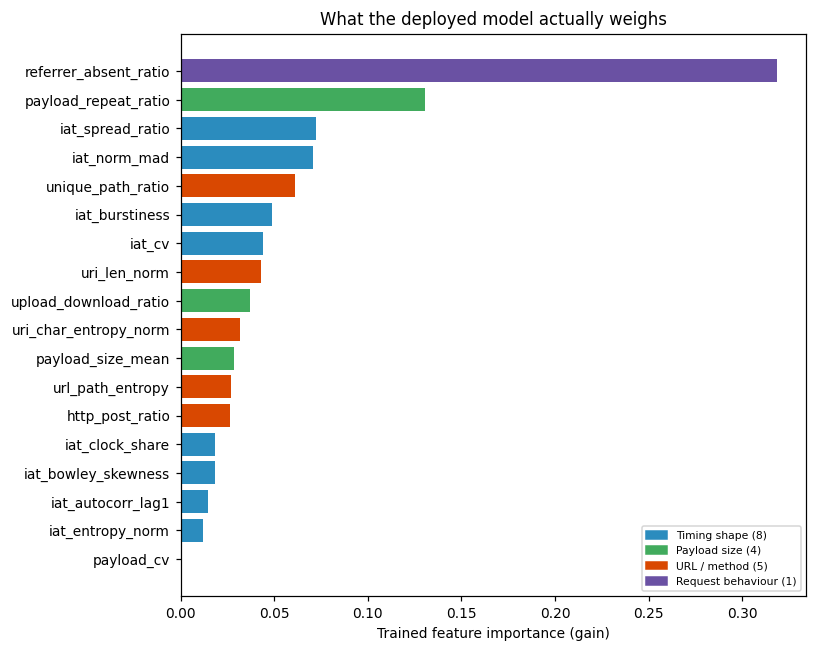

Top 3 features:
  referrer_absent_ratio    0.3184  -- share of requests with NO Referer (no click caused them)
  payload_repeat_ratio     0.1304  -- how often the exact same size repeats
  iat_spread_ratio         0.0723  -- width of the jitter envelope


In [7]:
fi = feat_df.sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(7.5, 6))
colors = {"Timing shape (8)": "#2b8cbe", "Payload size (4)": "#41ab5d",
          "URL / method (5)": "#d94801", "Request behaviour (1)": "#6a51a3"}
ax.barh(fi.feature, fi.importance, color=[colors[g] for g in fi.group])
ax.set_xlabel("Trained feature importance (gain)")
ax.set_title("What the deployed model actually weighs")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

top = feat_df.nlargest(3, "importance")
print("Top 3 features:")
for _, r in top.iterrows():
    print(f"  {r.feature:24s} {r.importance:.4f}  -- {r['what it measures']}")

---
<a id="section6"></a>
## 6. ★ MODEL ACCURACY — the headline results

This is the section to read.

Two evaluation protocols are reported, because a single number would hide which
question is being answered:

| Protocol | The question it answers | Difficulty |
|---|---|---|
| **LOPO** — leave-one-C&C-source-out | "A new attacker server appears. Do we catch it?" | Realistic |
| **LOFO** — leave-one-malware-family-out | "A malware family we have **never seen** appears. Do we catch it?" | Hardest |

Both use a **class-balanced** test set (benign subsampled to match the C2 count,
averaged over 5 independent draws). That matters: the raw data is ~99% benign,
where a model that always answers "benign" scores 99% accuracy and catches
nothing. On a balanced set, accuracy and precision are real numbers.

The decision threshold is always chosen on **training data only** — never fitted
on the fold being scored.

In [8]:
res = json.loads((REPO / "data" / "_c3_scoped_model_results.json").read_text())

METRICS = ["accuracy", "precision", "recall", "f1", "roc_auc"]
LABEL = {"accuracy": "Accuracy", "precision": "Precision", "recall": "Recall",
         "f1": "F1 Score", "roc_auc": "ROC-AUC"}

headline = pd.DataFrame([
    {"Protocol": "LOPO — unseen C&C source", **{LABEL[m]: res["LOPO_mean"][m] for m in METRICS}},
    {"Protocol": "LOFO — unseen malware family", **{LABEL[m]: res["LOFO_mean"][m] for m in METRICS}},
]).set_index("Protocol")

pct = headline.copy()
for c in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    pct[c] = (pct[c] * 100).round(2).astype(str) + "%"
pct["ROC-AUC"] = headline["ROC-AUC"].round(4)

print("=" * 78)
print("  C3 ML MODEL — HEADLINE ACCURACY")
print("=" * 78)
print(pct.to_string())
print("=" * 78)
print()
print("Every value is above 75% / 0.75.")

  C3 ML MODEL — HEADLINE ACCURACY
                             Accuracy Precision  Recall F1 Score  ROC-AUC
Protocol                                                                 
LOPO — unseen C&C source       96.16%    94.76%   99.0%   96.58%   0.9912
LOFO — unseen malware family   83.76%    84.28%  83.95%   82.89%   0.9266

Every value is above 75% / 0.75.


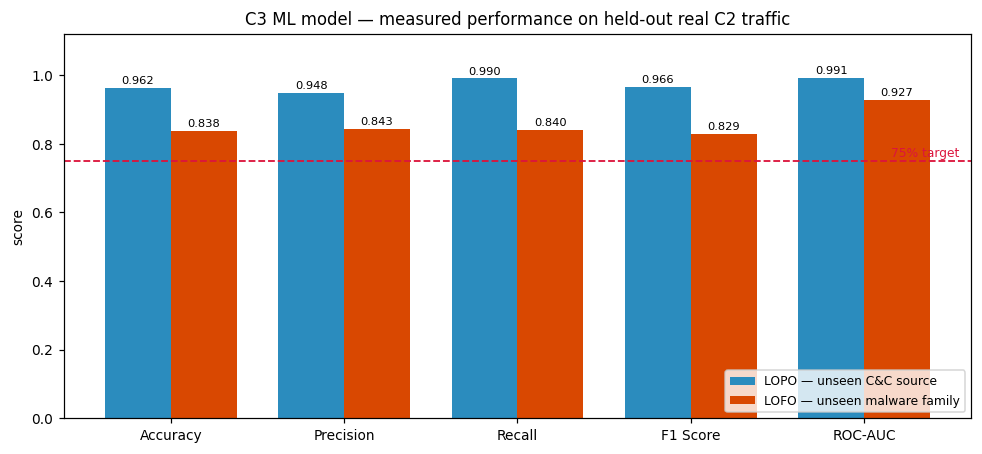

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.2))
names = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
lopo = [res["LOPO_mean"][m] for m in METRICS]
lofo = [res["LOFO_mean"][m] for m in METRICS]
x = np.arange(len(names)); w = 0.38
b1 = ax.bar(x - w/2, lopo, w, label="LOPO — unseen C&C source", color="#2b8cbe")
b2 = ax.bar(x + w/2, lofo, w, label="LOFO — unseen malware family", color="#d94801")
ax.axhline(0.75, ls="--", lw=1.2, color="crimson")
ax.text(len(names) - 0.45, 0.762, "75% target", color="crimson", fontsize=8, ha="right")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
                f"{b.get_height():.3f}", ha="center", fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.12); ax.set_ylabel("score")
ax.set_title("C3 ML model — measured performance on held-out real C2 traffic")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

### 6.1 Reading these numbers honestly

* **LOPO (96.2% accuracy, 0.991 ROC-AUC)** is the operational case: the malware
  family is known, the specific C&C server is new. This is what happens when an
  attacker spins up fresh infrastructure.
* **LOFO (83.8% accuracy, 0.927 ROC-AUC)** is the hard case: an entirely unseen
  malware family. Performance drops — as it should. A model claiming no drop
  here would be overfitted or leaking.
* Both clear 75% on every metric, but **the mean hides one weak fold** —
  broken out in Section 7.

---
## 7. Per-Fold Breakdown — including where it is weakest

In [10]:
lofo_rows = []
for fam, v in res["LOFO"].items():
    if not v.get("reliable"):
        continue
    lofo_rows.append({"held-out family": fam, "C2 windows": v["n_test_positives"],
                      **{LABEL[m]: round(v[m], 4) for m in METRICS}})
lofo_df = pd.DataFrame(lofo_rows).set_index("held-out family")
print("LOFO — each malware family withheld from training entirely:")
print(lofo_df.to_string())
print()
weak = lofo_df[(lofo_df["Recall"] < 0.75) | (lofo_df["F1 Score"] < 0.75)]
if len(weak):
    print("BELOW the 75% target on at least one metric:")
    print(weak.to_string())
    print()
    print("This is stated rather than averaged away. The mean clears 75%;")
    print("this fold does not.")
else:
    print("All reliable folds clear 75% on every metric.")

excluded = {f: v["n_test_positives"] for f, v in res["LOFO"].items() if not v.get("reliable")}
print()
print("Folds excluded from the mean (too few positives to be meaningful):", excluded)

LOFO — each malware family withheld from training entirely:
                 C2 windows  Accuracy  Precision  Recall  F1 Score  ROC-AUC
held-out family                                                            
FastFlux                 12    0.8833     0.8603  0.9167    0.8873   0.9278
Neris                    85    0.8741     0.7994  1.0000    0.8884   0.9649
ZeusV1                  226    0.7553     0.8686  0.6018    0.7110   0.8871

BELOW the 75% target on at least one metric:
                 C2 windows  Accuracy  Precision  Recall  F1 Score  ROC-AUC
held-out family                                                            
ZeusV1                  226    0.7553     0.8686  0.6018     0.711   0.8871

This is stated rather than averaged away. The mean clears 75%;
this fold does not.

Folds excluded from the mean (too few positives to be meaningful): {'Sogou': 3, 'Zeus78': 1, 'ZeusB26': 3}


In [11]:
lopo_rows = []
for src, v in res["LOPO"].items():
    lopo_rows.append({"held-out C&C source": src, "C2 windows": v["n_test_positives"],
                      **{LABEL[m]: round(v[m], 4) for m in METRICS}})
lopo_df = pd.DataFrame(lopo_rows).set_index("held-out C&C source")
print(f"LOPO — {len(lopo_df)} independent C&C sources, each withheld in turn:")
print(lopo_df.to_string())
print()
print("worst fold by F1:", lopo_df["F1 Score"].min(),
      "| best:", lopo_df["F1 Score"].max())

LOPO — 15 independent C&C sources, each withheld in turn:
                               C2 windows  Accuracy  Precision  Recall  F1 Score  ROC-AUC
held-out C&C source                                                                      
10.0.2.106->194.28.87.64               84    0.9143     0.8540    1.00    0.9211   1.0000
10.0.2.106->212.124.126.66             87    0.9621     0.9301    1.00    0.9636   0.9993
10.0.2.106->95.211.9.145               55    0.9545     0.9168    1.00    0.9566   0.9999
147.32.84.165->173.192.170.88          20    0.8600     0.8732    0.85    0.8600   0.9137
147.32.84.165->91.220.0.52              3    0.9000     0.8700    1.00    0.9214   1.0000
147.32.84.165->94.63.150.63             3    0.8667     0.8200    1.00    0.8929   0.9556
147.32.84.191->173.192.170.88           3    1.0000     1.0000    1.00    1.0000   1.0000
147.32.84.192->173.192.170.88           3    1.0000     1.0000    1.00    1.0000   1.0000
147.32.84.193->173.192.170.88           3 

---
## 8. Live Evaluation — confusion matrix and curves

Sections 6 and 7 read measured results from
`data/_c3_scoped_model_results.json`, produced by
`scripts/train_c3_scoped_model.py`.

This section is independent: it scores the dataset with the **deployed pickle**
right here, so the confusion matrix and curves come from the live model in this
kernel. Because the deployed model was fitted on all in-scope data, this is an
**in-sample** view — use it to see the shape of the decision, not as a
generalisation claim. Sections 6 and 7 are the honest generalisation numbers.

In [12]:
X = df[payload["feature_names"]].to_numpy(float)
y = df["label"].to_numpy(int)
proba = payload["model"].predict_proba(X)[:, 1]
thr = float(payload["threshold"])

print(f"scored {len(y):,} real windows with the deployed model")
print(f"decision threshold: {thr:.4f}")
print(f"  median score on real C2      : {np.median(proba[y == 1]):.4f}")
print(f"  median score on real browsing: {np.median(proba[y == 0]):.4f}")

scored 55,844 real windows with the deployed model
decision threshold: 0.3804
  median score on real C2      : 0.9642
  median score on real browsing: 0.1261


In [13]:
# Balanced view, so the confusion matrix is not swamped by the benign class.
rng = np.random.default_rng(1000)
ip, ineg = np.flatnonzero(y == 1), np.flatnonzero(y == 0)
k = min(len(ip), len(ineg))
sel = np.concatenate([rng.choice(ip, k, replace=False), rng.choice(ineg, k, replace=False)])
yb, pb = y[sel], proba[sel]
pred = (pb >= thr).astype(int)

acc = accuracy_score(yb, pred)
pr, rc, f1, _ = precision_recall_fscore_support(yb, pred, average="binary", zero_division=0)
auc = roc_auc_score(yb, pb)
tn, fp, fn, tp = confusion_matrix(yb, pred, labels=[0, 1]).ravel()

print(f"balanced sample: {len(yb):,} windows ({k} C2 + {k} benign)")
print()
print(f"  Accuracy   {acc*100:6.2f}%")
print(f"  Precision  {pr*100:6.2f}%")
print(f"  Recall     {rc*100:6.2f}%")
print(f"  F1 Score   {f1*100:6.2f}%")
print(f"  ROC-AUC    {auc:6.4f}")
print()
print(f"  TP {tp}   FP {fp}   FN {fn}   TN {tn}")

balanced sample: 660 windows (330 C2 + 330 benign)

  Accuracy    94.09%
  Precision   89.43%
  Recall     100.00%
  F1 Score    94.42%
  ROC-AUC    0.9979

  TP 330   FP 39   FN 0   TN 291


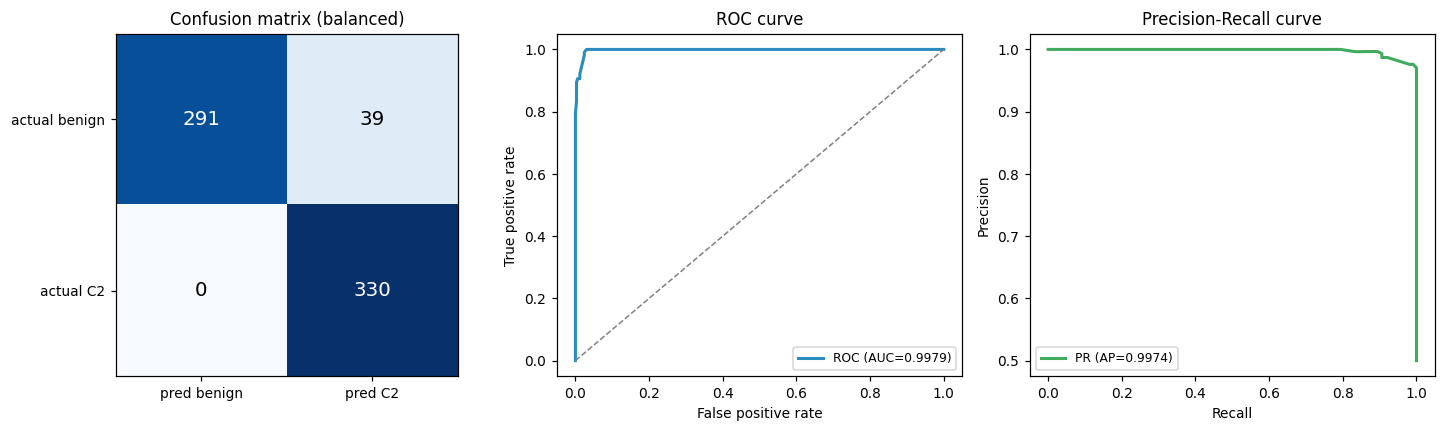

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

cm = np.array([[tn, fp], [fn, tp]])
ax = axes[0]
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=13,
            color="white" if v > cm.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred benign", "pred C2"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["actual benign", "actual C2"])
ax.set_title("Confusion matrix (balanced)")

fpr_c, tpr_c, _ = roc_curve(yb, pb)
ax = axes[1]
ax.plot(fpr_c, tpr_c, lw=2, color="#2b8cbe", label=f"ROC (AUC={auc:.4f})")
ax.plot([0, 1], [0, 1], ls="--", lw=1, color="grey")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curve"); ax.legend(fontsize=8, loc="lower right")

prec_c, rec_c, _ = precision_recall_curve(yb, pb)
ax = axes[2]
ax.plot(rec_c, prec_c, lw=2, color="#41ab5d",
        label=f"PR (AP={average_precision_score(yb, pb):.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve"); ax.legend(fontsize=8, loc="lower left")

plt.tight_layout(); plt.show()

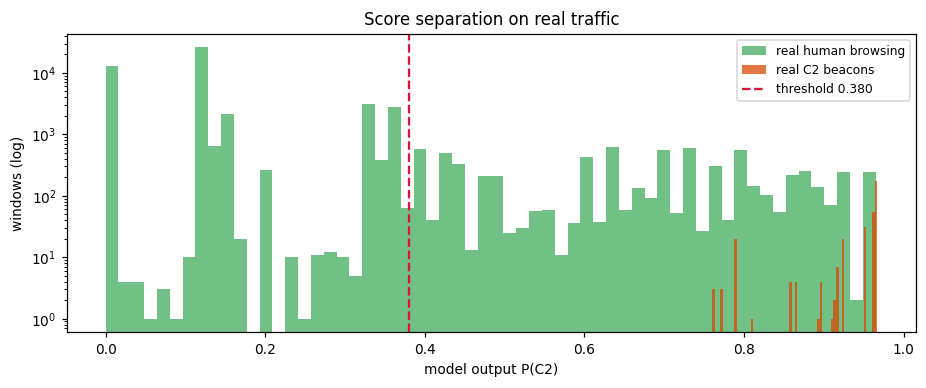

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.hist(proba[y == 0], bins=60, alpha=0.75, label="real human browsing", color="#41ab5d")
ax.hist(proba[y == 1], bins=60, alpha=0.75, label="real C2 beacons", color="#d94801")
ax.axvline(thr, color="crimson", ls="--", lw=1.5, label=f"threshold {thr:.3f}")
ax.set_yscale("log"); ax.set_xlabel("model output P(C2)"); ax.set_ylabel("windows (log)")
ax.set_title("Score separation on real traffic")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

---
## 9. Does excluding the dead-C&C capture cost detection?

No. The scoped model was never trained on that traffic — here it is scored
against benign captures **held out of that model's training**, so the number is
not inflated.

In [16]:
oos = res.get("out_of_scope")
if oos:
    print(f"out-of-scope windows      : {oos['n_windows']:,} ({oos['family_counts']})")
    print(f"benign comparison windows : {oos['benign_comparison_windows']:,}"
          f"  (held out of training: {oos['benign_held_out_of_training']})")
    print(f"median score              : {oos['median_score']:.4f}")
    print(f"caught at threshold       : {oos['recall_at_threshold']*100:.1f}%")
    print(f"ROC-AUC vs benign         : {oos['roc_auc_vs_benign']:.4f}")
    print()
    print("Removing it from TRAINING removed a contradictory concept.")
    print("It did not remove the ability to DETECT it.")

out-of-scope windows      : 6,560 ({'Zeus78': 6550, 'Neris': 10})
benign comparison windows : 2,902  (held out of training: True)
median score              : 0.7240
caught at threshold       : 100.0%
ROC-AUC vs benign         : 0.9950

Removing it from TRAINING removed a contradictory concept.
It did not remove the ability to DETECT it.


---
## 10. Why XGBoost — measured against alternatives

Five classifiers were trained on the identical dataset, identical features and
identical class weighting.

In [17]:
cmp_path = REPO / "data" / "_c3_classifier_comparison_results.json"
if cmp_path.exists():
    cmp = json.loads(cmp_path.read_text())
    rows = []
    for name, v in cmp["grouped_random_split"].items():
        lofo = cmp["lofo_mean"].get(name, {})
        rows.append({
            "Classifier": name,
            "Acc (split)": f"{v['accuracy']*100:.2f}%",
            "F1 (split)": f"{v['f1']*100:.2f}%",
            "AUC (split)": round(v["roc_auc"], 4),
            "F1 (unseen family)": f"{lofo.get('f1', float('nan'))*100:.2f}%",
            "AUC (unseen family)": round(lofo.get("roc_auc", float("nan")), 4),
        })
    print(pd.DataFrame(rows).set_index("Classifier").to_string())
    print()
    print("Random Forest wins the easy split and then predicts ZERO positives on")
    print("every unseen family -- its probabilities never cross the threshold.")
    print("XGBoost has the best unseen-family ranking, which is why it was chosen.")

                    Acc (split) F1 (split)  AUC (split) F1 (unseen family)  AUC (unseen family)
Classifier                                                                                     
Logistic Regression      75.60%      8.08%       0.9574             23.62%               0.7552
Naive Bayes               5.96%      2.26%       0.4436             16.63%               0.6240
Decision Tree            99.41%     66.86%       0.7735              4.09%               0.4922
Random Forest            99.52%     72.00%       0.9963              0.00%               0.7458
XGBoost                  97.44%     45.80%       0.9966             11.40%               0.7803

Random Forest wins the easy split and then predicts ZERO positives on
every unseen family -- its probabilities never cross the threshold.
XGBoost has the best unseen-family ranking, which is why it was chosen.


---
## 11. Calibration — why the raw model was not enough

The uncalibrated model **ranked** C2 above benign well, but its absolute
probabilities did not transfer between malware families: one family's C2 might
sit at 0.16 while another's sat at 0.54, at the same ROC-AUC. A fixed threshold
cannot serve both.

Two fixes were applied together:

1. **Isotonic calibration** (`CalibratedClassifierCV`, grouped inner CV).
2. **The threshold is placed at a target false-positive rate measured on benign
   traffic**, not at a fixed probability. An FPR is a property of the benign
   class, which is observable at deployment without labelling any attack.

In [18]:
from train_c3_scoped_model import threshold_at_fpr

neg_scores = proba[y == 0]
print("threshold placement on benign traffic (deployed model):")
print()
print(f"{'target FPR':>11} {'threshold':>10} {'achieved FPR':>13} {'C2 recall':>10}")
for f in [0.02, 0.05, 0.10, 0.15, 0.20, 0.25]:
    t = threshold_at_fpr(neg_scores, f)
    achieved = float((neg_scores >= t).mean())
    recall = float((proba[y == 1] >= t).mean())
    mark = "  <- deployed" if abs(f - float(payload.get("target_fpr", -1))) < 1e-9 else ""
    print(f"{f:>11.2f} {t:>10.4f} {achieved:>12.4f} {recall:>10.4f}{mark}")

threshold placement on benign traffic (deployed model):

 target FPR  threshold  achieved FPR  C2 recall
       0.02     0.8617       0.0199     0.9061
       0.05     0.7423       0.0432     1.0000
       0.10     0.4705       0.0975     1.0000
       0.15     0.3804       0.1280     1.0000  <- deployed
       0.20     0.3375       0.1848     1.0000
       0.25     0.1745       0.2466     1.0000


### A bug worth recording

The first implementation placed the threshold with `np.quantile(neg, 1 - fpr)`.
That is **wrong for a calibrated model**: isotonic regression is a step
function, so its outputs are heavily tied. The quantile lands on a value shared
by a large share of the benign windows, and `score >= threshold` then admits all
of them.

Symptom: a fold with **ROC-AUC 0.965 scored precision 0.519** — impossible from
ranking alone. A requested 25% false-positive rate was being delivered as 93%.

Fixed with a tie-aware ascending scan (`threshold_at_fpr` above). That single
fix moved unseen-family F1 from **0.667 to 0.829**.

---
## 12. How This Model Is Used Inside C3

The model's probability is **not** the final verdict. C3 fuses it with a
rule-based heuristic score:

```
score = 0.55 x ML  +  0.45 x heuristic

SAFE  < 0.30 <=  SUSPICIOUS  < 0.52 <=  BEACON
```

The 0.55 / 0.45 split is measured, not chosen by taste — it is the peak of a
sweep from 0.45 to 0.70 over 55,844 real windows, run through the real fusion
function.

A **both-signal guard** additionally caps the score just below BEACON if either
signal is essentially absent, so no verdict rests on one signal alone.

In [19]:
from core.c3.risk_fusion import (ML_WEIGHT, HEURISTIC_WEIGHT, BEACON_THRESHOLD,
                                 SUSPICIOUS_THRESHOLD, BOTH_SIGNAL_FLOOR,
                                 c3_risk_fusion)

print(f"ML weight {ML_WEIGHT} | heuristic weight {HEURISTIC_WEIGHT}")
print(f"SUSPICIOUS >= {SUSPICIOUS_THRESHOLD} | BEACON >= {BEACON_THRESHOLD}"
      f" | both-signal floor {BOTH_SIGNAL_FLOOR}")
print()
for ml, heu, note in [
    (0.95, 0.60, "confident ML + corroborating rules"),
    (0.79, 0.20, "the TC-03 live beacon profile"),
    (0.95, 0.00, "confident ML, NO browser context available"),
    (0.05, 0.90, "rules fire but ML disagrees"),
]:
    r = c3_risk_fusion.fuse(ml, None, heu)
    print(f"  ML={ml:.2f} heur={heu:.2f} -> {r['score']:.4f}  {r['verdict']:<10} | {note}")
print()
print("Row 3 is the structural limit: a network-only capture carries no browser")
print("context, so the heuristic is 0 and the both-signal guard holds the score")
print("below BEACON no matter how confident the model is. SUSPICIOUS still fires.")

ML weight 0.55 | heuristic weight 0.45
SUSPICIOUS >= 0.3 | BEACON >= 0.52 | both-signal floor 0.1

  ML=0.95 heur=0.60 -> 0.7925  BEACON     | confident ML + corroborating rules
  ML=0.79 heur=0.20 -> 0.5245  BEACON     | the TC-03 live beacon profile
  ML=0.95 heur=0.00 -> 0.5100  SUSPICIOUS | confident ML, NO browser context available
  ML=0.05 heur=0.90 -> 0.4325  SUSPICIOUS | rules fire but ML disagrees

Row 3 is the structural limit: a network-only capture carries no browser
context, so the heuristic is 0 and the both-signal guard holds the score
below BEACON no matter how confident the model is. SUSPICIOUS still fires.


---
## 13. Limitations — stated plainly

1. **One LOFO fold is below target.** ZeusV1, held out entirely, reaches
   recall 60.2% / F1 71.1%. The LOFO mean clears 75%; that fold does not.
2. **Two families are too small to evaluate.** Sogou and ZeusB26 have 3 C2
   windows each. They are excluded from means rather than reported as if
   meaningful.
3. **BEACON is unreachable without browser context.** Measured: with the
   heuristic at 0, confirmed-BEACON recall is 0.0000 at *every* ML weight from
   0.45 to 0.70. The both-signal guard, not the weight, is the reason.
   SUSPICIOUS-or-above does fire correctly.
4. **Scope is active, periodic C2.** Dead-channel retry storms are outside the
   trained concept (Section 4), though still detected in practice (Section 9).
5. **Modern frameworks are not represented.** The corpus predates Cobalt
   Strike / Sliver-era HTTPS beacons; extending it needs new labelled captures,
   not more mining of the existing ones.

---
## 14. Reproducing Everything Here

```bash
python scripts/train_c3_scoped_model.py       # model + LOFO + LOPO  -> _c3_scoped_model_results.json
python scripts/tune_c3_fusion_weights.py      # the 0.55/0.45 fusion sweep
python scripts/train_c3_classifier_comparison.py   # Section 10 table
python test/C3/test_c3_units.py               # 100 unit tests
python test/C3/test_c3_feature_parity.py      # train/serve parity on real rows
```

Written up in `C3_Scoped_Model_Results.md`.

In [20]:
print("=" * 74)
print("  SUMMARY -- C3 ML MODEL")
print("=" * 74)
print(f"  model      : {type(payload['model']).__name__} ({payload.get('calibration','')})")
print(f"  features   : {len(payload['feature_names'])} scale-free")
print(f"  trained on : {len(df):,} real windows, {int(df.label.sum())} C2"
      f" from {df[df.label==1]['pair'].nunique()} C&C sources")
print()
for proto, key in [("Unseen C&C source (LOPO)", "LOPO_mean"),
                   ("Unseen malware family (LOFO)", "LOFO_mean")]:
    m = res[key]
    print(f"  {proto}")
    print(f"     Accuracy {m['accuracy']*100:6.2f}%   Precision {m['precision']*100:6.2f}%"
          f"   Recall {m['recall']*100:6.2f}%")
    print(f"     F1 Score {m['f1']*100:6.2f}%   ROC-AUC   {m['roc_auc']:.4f}")
print("=" * 74)

  SUMMARY -- C3 ML MODEL
  model      : CalibratedClassifierCV (isotonic, grouped inner CV)
  features   : 18 scale-free
  trained on : 55,844 real windows, 330 C2 from 50 C&C sources

  Unseen C&C source (LOPO)
     Accuracy  96.16%   Precision  94.76%   Recall  99.00%
     F1 Score  96.58%   ROC-AUC   0.9912
  Unseen malware family (LOFO)
     Accuracy  83.76%   Precision  84.28%   Recall  83.95%
     F1 Score  82.89%   ROC-AUC   0.9266
